<a href="https://colab.research.google.com/github/evandwh/ST554---Spring-2026---NCSU/blob/main/Whitfield_ST554_HW5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Author:** Evan Whitfield

**Couse:** ST 554 - NC State University

**Purpose:** Homework #5

#Part 1

## Number 1 - The 5 V's of Big Data

**Using the Actions in Soccer Games to Predict Outcomes**

`Velocity` - Data comes in very quickly during soccer matches. There are several soccer matches going on every day. Sometimes we may want to use the data from the current game (Half time) so we would need to be able to compile results quickly.

`Veracity` - Different sources will attempt to collect data in real time. Instruments may be slightly off and manual entry methods may mistakes. If we have different values from different manual entries, then it is important to verify which entry was correct before building out model to make predicts. We don't want to make predictions on incorrect data.


`Variety` - GPS data, athletic tracking equipment the players where, JSON files, etc.


`Value` - Owners of major clubs pay billions of dollars to own a team, then spend millions of dollars each year on players, wages, equipment, etc. They want a profitable team, which usually means winning. Need to select the right players to win, the right manager with the right tactics. A bad season could mean a high loss in capital.


`Volume` - There are thousands, if not millions of data points for each soccer game. If we are using GPS data to track player position, then each players movement every second could be recorded. That’s 22 total players, with 5400 seconds worth of “game time”, resulting in 118,800 positions of players in a single game. Then you also want to track the ball as well, but also the action that caused the ball to move the way that it did. We want to be able to count the number of sprints a player runs, how far they run, how many times they complete a pass, how many times they fail a pass, how many times they try to dribble past an opponent. All in one season. Multiply that times a 38 match season (for a 20 team league), plus cup games and then over several seasons if you want to follow a single player or group of players at one club.




## Number 2 - CRUD


**`C`reate** – Every season, new players are going to join the MLB, meaning that new names needed to be created in the database.

**`R`ead** – We might want to see how a certain batter performed against certain pitchers. We need to be able to read the data that is valuable for that scenario.

**`U`pdate** – Every game presents new data for us to add to the database. A batter is going to increase his number of at bats, or a pitcher will increase he number of pitches thrown. These could be considered Creating Data, so I will mention that sometimes there are adjustments that are made to the stats. A play might initially be ruled a hit, but it was ruled an error later in the game (or after the game). This seems to happen more in football than baseball when they are updating yardages/etc. Also, maybe a player is traded to a new team and his team needs to be changed in the database.

**`D`elete** – If there is anything erroneous entered in that has been changed, then that data needs to be deleted.

##Number 3

HAVING is a command to add a filter or search criterion to groups after a GROUP BY statement has been made. This is when you want to return any groups that have met the HAVING criteria.


#Part II -

Below is code to generate the 33 random errors for data that is to follow a population slope of 1.5 with a population intercept of 7.  We will be simulating errors to determine the slope of the simple linear regression model for our generated data.

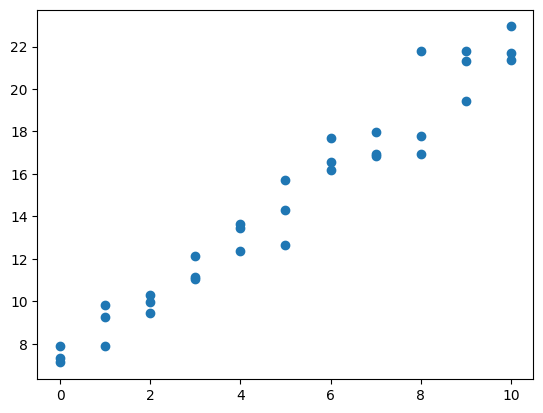

In [30]:
#import some modules needed
import matplotlib.pyplot as plt
import numpy as np
from numpy.random import default_rng
from sklearn.linear_model import LinearRegression

ng = default_rng(32)
beta_0 = 7
beta_1 = 1.5

# get three 'values' of x at each integer from 0 to 10.
x = np.array(list(np.linspace(start = 0, stop = 10, num = 11))*3)
n = 33

#create the 'responses' modeled from the line plus a random deviation
y = beta_0 + beta_1*x + ng.standard_normal(n)

#visualize the data
plt.scatter(x = x, y = y)
plt.show()

The graph above shows an example of a scatterplot of 33 points along the population model of y = 7 + 1.5*x.

Now we want to repeat this 5000 times and determine the distribution of the possible slopes we could get.  I have added a red line at at 1.65 to show where the *large* slopes will be located.

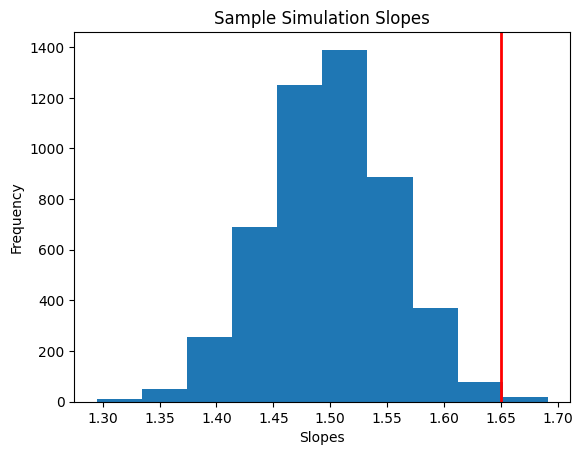

0.0044


In [34]:
#Necessary start
slopes = []
reg = LinearRegression()

#create the 'responses' modeled from the line plus a random deviation
for _ in range(0, 5000):
    y = beta_0 + beta_1*x + ng.standard_normal(n)
    reg.fit(x.reshape(-1, 1), y)
    slope = reg.coef_[0]
    slopes.append(slope)

#Plot histogram of simulated slopes
plt.hist(slopes)
plt.xlabel('Slopes')
plt.ylabel('Frequency')
plt.title('Sample Simulation Slopes')
plt.axvline(1.65, color='red', linewidth=2)
plt.show()

In [35]:
#Count the large slopes are turn it into a proportion
large_slopes = [x for x in slopes if x > 1.65]
prop = len(large_slopes) / len(slopes)

print(prop)


0.0044


 Based off the histogram, you can see that there are very few observations that are above 1.65.  Only .44% of the simulations recorded a sample slope above 1.65, when our population slope was 1.5.  Because this value is very low, it would be highly unlikely for us to collect data and get a sample slope of 1.65, given a population slope of 1.5. If we were to record a sample slope greater than 1.65, it would give us significant evidence that the population slope was not 1.5. We would conclude that the population slope was greater than 1.5.

#Part 3 - Big Data Examples and Rare Events

## Number 5

In-Group and out-group attribution bias -

In-group bias refers to a tendency to favor those that are similar in some way to yourself, while Out-Group bias refers to a tendency to stereotype individuals that are different from you in some way, or that are included in a different group that you.

If a model is trained on data that comes from a certain group of people, or that favors a certain group of people, then the results from the model will also favor those people. For example, if the model is trained to show that all CEOs are white, males with PhDs, then the model would believe that a white male with a PhD is the best candidate for a CEO position. Likewise, if the model is trained on crime data showing that African-American's or Hispanic's males are convicted of certain crimes, then the model will tend to select an African-America or Hispanic male as the criminal in a future case.

We can combat this by making sure that there is one variable that appears in an overabundance in our data set. Do not undercover different groups of people in your training data. We want to use some kind of metric that will ensure equal performance across all groups if possible.


## Number 6

I am very interested in mapping the ocean in 3D. Since there is usually not visible landmarks, any person doing research and collecting data on the ocean must rely heavily on GPS and other location instruments, including those for depth. The sheer volume of the ocean means the data needed to map the entire thing must be astronomically large.

Bias could be introduced if any of the location tracking machines are off. There are a variety of different methods used to collect data the data. These tools must be able to communicate with one other quickly. If location data cannot be stored, then much of the other taken will be wasted and lead to a data swamp.

## Number 7

In the medical field, there are certain diseases and disorders that have a very low rate of occurence. The doctors need to be able to determine if certain signs and symptoms are a more common disease or disorder before moving on the less common ideas. This changes what they might want to do to treat the disease or disorder, whether it is to try to treat/cure the cause of it, or rather just help with the symptoms. The more data that doctors have, the easier it becomes to determine different possibilites. However, since every patient is different and reacts different, they are constantly learning and creating more data that can be used to help future patients. Some of these combinations are so rare that doctors would never think of them, but that does not mean they do not exist. Furthermore, since they are so rare, there is not a lot of data for treatment/causes/other symptoms/etc.

#Part 4

##Number 8

In [42]:
#import sql and pandas
import sqlite3
import pandas as pd


#Create connection
con = sqlite3.connect('/content/drive/MyDrive/Colab Notebooks/Colab Data/lahman_1871-2022 (2).sqlite')

#create a 'cursor' object from our connection
cursor = con.cursor()

#get schema code
get_schema = '''
        SELECT *
        FROM sqlite_schema
        WHERE type = "table";
        '''

schema_df = pd.read_sql(get_schema, con)

print(schema_df)

     type                 name             tbl_name  rootpage  \
0   table          AllstarFull          AllstarFull         2   
1   table          Appearances          Appearances         3   
2   table       AwardsManagers       AwardsManagers         4   
3   table        AwardsPlayers        AwardsPlayers         5   
4   table  AwardsShareManagers  AwardsShareManagers         6   
5   table   AwardsSharePlayers   AwardsSharePlayers         7   
6   table              Batting              Batting         8   
7   table          BattingPost          BattingPost         9   
8   table       CollegePlaying       CollegePlaying        10   
9   table             Fielding             Fielding        11   
10  table           FieldingOF           FieldingOF        12   
11  table      FieldingOFsplit      FieldingOFsplit        13   
12  table         FieldingPost         FieldingPost        14   
13  table           HallOfFame           HallOfFame        15   
14  table            Home

##Number 9

In [45]:
get_teams_1 = '''
        SELECT *
        FROM teams
        WHERE yearID = 2015
        '''

teams_1_df = pd.read_sql(get_teams_1, con)

teams_1_df

,yearID,lgID,teamID,franchID,divID,Rank,G,Ghome,W,L,...,DP,FP,name,park,attendance,BPF,PPF,teamIDBR,teamIDlahman45,teamIDretro
0,2015,AL,BAL,BAL,E,3,162,78,81,81,...,134,0.987,Baltimore Orioles,Oriole Park at Camden Yards,2281202,103,104,BAL,BAL,BAL
1,2015,AL,BOS,BOS,E,5,162,81,78,84,...,148,0.984,Boston Red Sox,Fenway Park II,2880694,104,107,BOS,BOS,BOS
2,2015,AL,CHA,CHW,C,4,162,81,76,86,...,159,0.983,Chicago White Sox,U.S. Cellular Field,1755810,92,93,CHW,CHA,CHA
3,2015,AL,CLE,CLE,C,3,161,80,81,80,...,136,0.987,Cleveland Indians,Progressive Field,1388905,106,106,CLE,CLE,CLE
4,2015,AL,DET,DET,C,5,161,81,74,87,...,165,0.986,Detroit Tigers,Comerica Park,2726048,97,98,DET,DET,DET
5,2015,AL,HOU,HOU,W,2,162,81,86,76,...,131,0.986,Houston Astros,Minute Maid Park,2153585,97,99,HOU,HOU,HOU
6,2015,AL,KCA,KCR,C,1,162,81,95,67,...,138,0.985,Kansas City Royals,Kauffman Stadium,2708549,104,103,KCR,KCA,KCA
7,2015,AL,LAA,ANA,W,3,162,81,85,77,...,108,0.984,Los Angeles Angels of Anaheim,Angel Stadium of Anaheim,3012765,94,95,LAA,ANA,ANA
8,2015,AL,MIN,MIN,C,2,162,81,83,79,...,150,0.986,Minnesota Twins,Target Field,2220054,103,104,MIN,MIN,MIN
9,2015,AL,NYA,NYY,E,2,162,81,87,75,...,135,0.985,New York Yankees,Yankee Stadium III,3193795,99,101,NYY,NYA,NYA


##Number 10

In [48]:
get_HoF = '''
        SELECT playerID, yearID, category
        FROM HallOfFame
        WHERE inducted = 'Y'
        '''

HoF_df = pd.read_sql(get_HoF, con)

HoF_df

,playerID,yearid,category
0,aaronha01,1982,Player
1,alexape01,1938,Player
2,alomaro01,2011,Player
3,alstowa01,1983,Manager
4,andersp01,2000,Manager
...,...,...,...
335,yastrca01,1989,Player
336,yawketo99,1980,Pioneer/Executive
337,youngcy01,1937,Player
338,youngro01,1972,Player


##Number 11

In [52]:
Pitt_managers = '''
              SELECT DISTINCT playerID
              FROM Managers
              WHERE TeamId = 'PIT'
              '''

Pitt_managers_df = pd.read_sql(Pitt_managers, con)

Pitt_managers_df

,playerID
0,bezdehu99
1,bragabo01
2,buckeal99
3,burnsto01
4,burwebi01
5,bushdo01
6,callani01
7,clarkfr01
8,davissp01
9,donovpa01


##Number 12

The instructions to me were unclear, so I did this two different ways just to be on the safe side.

In [66]:
#First Way
HoF_Managers = '''
              SELECT HallOfFame.playerID
              FROM HallOfFame
              INNER JOIN Managers
              ON Managers.playerID = HallOfFame.playerID
              WHERE inducted = 'Y'
              '''

HoF_Managers_df = pd.read_sql(HoF_Managers, con)

HoF_Managers_df

,playerID
0,alstowa01
1,alstowa01
2,alstowa01
3,alstowa01
4,alstowa01
...,...
991,wrighha01
992,wrighha01
993,wrighha01
994,wrighha01


In [67]:
HoF_Managers_df['playerID'].nunique()

97

In [69]:
#Second Way
HoF_Managers_dist = '''
              SELECT DISTINCT HallOfFame.playerID
              FROM HallOfFame
              INNER JOIN Managers
              ON Managers.playerID = HallOfFame.playerID
              WHERE inducted = 'Y'
              '''

HoF_Managers_dist_df = pd.read_sql(HoF_Managers_dist, con)

HoF_Managers_dist_df

,playerID
0,alstowa01
1,andersp01
2,ansonca01
3,applilu01
4,baineha01
...,...
92,willidi02
93,willite01
94,wrighge01
95,wrighha01


In [70]:
len(HoF_Managers_dist_df)

97

##Number 13

In [73]:
Final_Call = '''
              SELECT M.playerID, G, W, L
              FROM Managers as M
              INNER JOIN HallOfFame as H
              ON M.playerID = H.playerID
              WHERE inducted = 'Y'
              '''

Final_df = pd.read_sql(Final_Call, con)

Final_df

,playerID,G,W,L
0,alstowa01,154,92,62
1,alstowa01,154,98,55
2,alstowa01,154,93,61
3,alstowa01,154,84,70
4,alstowa01,154,71,83
...,...,...,...,...
991,wrighha01,46,22,23
992,wrighha01,138,68,69
993,wrighha01,155,87,66
994,wrighha01,133,72,57


In [75]:
summed_df = Final_df.groupby('playerID')[['W', 'L']].sum().reset_index()

summed_df

,playerID,W,L
0,alstowa01,2040,1613
1,andersp01,2194,1834
2,ansonca01,1296,947
3,applilu01,10,30
4,baineha01,1,3
...,...,...,...
92,willidi02,1571,1451
93,willite01,273,364
94,wrighge01,59,25
95,wrighha01,1225,885


In [77]:
summed_df['win_pct'] = summed_df['W'] / (summed_df['W'] + summed_df['L'])

summed_df

,playerID,W,L,win_pct
0,alstowa01,2040,1613,0.558445
1,andersp01,2194,1834,0.544687
2,ansonca01,1296,947,0.577798
3,applilu01,10,30,0.250000
4,baineha01,1,3,0.250000
...,...,...,...,...
92,willidi02,1571,1451,0.519854
93,willite01,273,364,0.428571
94,wrighge01,59,25,0.702381
95,wrighha01,1225,885,0.580569


In [79]:
sorted_percent = summed_df.sort_values(by='win_pct', ascending=False)

sorted_percent

,playerID,W,L,win_pct
75,simmote01,1,0,1.000000
94,wrighge01,59,25,0.702381
78,spaldal01,78,47,0.624000
57,mccarjo99,2125,1333,0.614517
19,comisch01,840,541,0.608255
...,...,...,...,...
8,bottoji01,21,56,0.272727
3,applilu01,10,30,0.250000
4,baineha01,1,3,0.250000
86,wagneho01,1,4,0.200000
